In [2]:
import pandas as pd
import numpy as np
import os

# Dosya yollarını listele (Doğru yolları kopyalamak için)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/country_level_stats.csv
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/README.md
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/mental_health_tech_2024.csv
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/dataset-metadata.json
/kaggle/input/datasets/harpartapsingh13/mental-health-prediction-dataset/mental_health_prediction.csv


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/country_level_stats.csv
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/README.md
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/mental_health_tech_2024.csv
/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/dataset-metadata.json
/kaggle/input/datasets/harpartapsingh13/mental-health-prediction-dataset/mental_health_prediction.csv


In [4]:
# Veri setlerini yükle
df_gaming = pd.read_csv('/kaggle/input/datasets/dreamtensor/gaming-addiction-and-mental-health-analysis/gaming_addiction.csv')
df_tech = pd.read_csv('/kaggle/input/datasets/anasriaz/mental-health-in-tech-global-survey-2024/mental_health_tech_2024.csv')
df_mental = pd.read_csv('/kaggle/input/datasets/harpartapsingh13/mental-health-prediction-dataset/mental_health_prediction.csv')

# Sütun isimlerini ve satır sayılarını incele
print("1. Gaming Dataset Columns:\n", df_gaming.columns.tolist(), f"| Shape: {df_gaming.shape}\n")
print("2. Tech Dataset Columns:\n", df_tech.columns.tolist(), f"| Shape: {df_tech.shape}\n")
print("3. Mental Health Dataset Columns:\n", df_mental.columns.tolist(), f"| Shape: {df_mental.shape}\n")


1. Gaming Dataset Columns:
 ['user_id', 'age', 'gender', 'country', 'occupation', 'income_level', 'years_gaming', 'preferred_genre', 'platform', 'device_type', 'rank_tier', 'daily_playtime_hours', 'weekly_play_sessions', 'late_night_sessions_hours', 'weekend_playtime_hours', 'consecutive_hours_max', 'multiplayer_ratio', 'toxic_chat_reports', 'rage_quit_frequency', 'in_game_purchases', 'monthly_spending_usd', 'lootbox_openings', 'subscription_status', 'stress_score', 'loneliness_score', 'dopamine_dependency_index', 'self_control_score', 'impulsiveness_score', 'anxiety_level', 'depression_indicator', 'emotional_stability', 'sleep_hours', 'exercise_frequency_per_week', 'caffeine_intake_cups_day', 'social_interaction_hours', 'relationship_status', 'gpa_or_performance_score', 'missed_deadlines', 'productivity_drop_percent', 'absenteeism_days', 'internet_speed_mbps', 'screen_time_total_hours', 'behavioral_cluster', 'addiction_score', 'addiction_binary', 'addiction_severity', 'burnout_probabi

In [5]:
# Her üç veri setinin sayısal özet istatistiklerini alalım
print("--- Gaming Veri Seti Özeti ---")
display(df_gaming[['age', 'daily_playtime_hours', 'stress_score', 'addiction_score', 'sleep_hours']].describe())

print("\n--- Tech Veri Seti Özeti ---")
display(df_tech[['age', 'burnout_score', 'work_life_balance_score', 'sleep_hours_per_night']].describe())

print("\n--- Genel Mental Health Veri Seti Özeti ---")
display(df_mental[['age', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours']].describe())

--- Gaming Veri Seti Özeti ---


,age,daily_playtime_hours,stress_score,addiction_score,sleep_hours
count,250.000000,250.000000,250.000000,250.00000,250.000000
mean,22.160000,6.153200,6.819200,38.74448,6.766400
std,5.455037,2.656902,1.704056,11.74977,1.144776
min,13.000000,0.500000,1.000000,12.28000,3.400000
25%,18.000000,4.225000,5.700000,29.88250,6.100000
50%,22.000000,6.450000,6.950000,39.87500,6.800000
75%,27.000000,8.175000,8.000000,47.11000,7.700000
max,40.000000,11.900000,10.000000,68.00000,9.500000



--- Tech Veri Seti Özeti ---


,age,burnout_score,work_life_balance_score,sleep_hours_per_night
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,31.651800,5.795060,5.973460,6.592780
std,7.240984,1.669548,1.593627,1.157206
min,18.000000,1.000000,1.000000,3.000000
25%,27.000000,4.600000,4.900000,5.800000
50%,32.000000,5.800000,6.000000,6.600000
75%,36.000000,6.900000,7.100000,7.400000
max,61.000000,10.000000,10.000000,10.000000



--- Genel Mental Health Veri Seti Özeti ---


,age,stress_level,anxiety_score,depression_score,sleep_hours
count,500.000000,472.000000,478.000000,478.000000,485.000000
mean,26.832000,5.993644,4.763598,4.953975,6.769691
std,7.735597,2.549294,2.338398,2.437043,1.939245
min,15.000000,1.000000,1.000000,1.000000,3.000000
25%,21.000000,4.000000,3.000000,3.000000,5.300000
50%,26.000000,6.000000,5.000000,5.000000,6.700000
75%,32.000000,8.000000,7.000000,7.000000,8.100000
max,52.000000,10.000000,10.000000,10.000000,12.000000


In [6]:
# 1. Genel Mental Health veri setindeki eksik verileri temizleyelim
df_mental_clean = df_mental.dropna().copy()

# 2. Gaming Veri Seti Korelasyonu (Önemli Metrikler)
print("--- Gaming Korelasyon Matrisi ---")
gaming_corr = df_gaming[['daily_playtime_hours', 'stress_score', 'addiction_score', 'sleep_hours']].corr()
print(gaming_corr, "\n")

# 3. Tech Veri Seti Korelasyonu
print("--- Tech Korelasyon Matrisi ---")
tech_corr = df_tech[['burnout_score', 'work_life_balance_score', 'sleep_hours_per_night']].corr()
print(tech_corr, "\n")

# 4. Genel Mental Health Korelasyonu
print("--- Genel Mental Health Korelasyon Matrisi ---")
mental_corr = df_mental_clean[['stress_level', 'anxiety_score', 'depression_score', 'sleep_hours']].corr()
print(mental_corr)

--- Gaming Korelasyon Matrisi ---
                      daily_playtime_hours  stress_score  addiction_score  \
daily_playtime_hours              1.000000      0.332935         0.861188   
stress_score                      0.332935      1.000000         0.273984   
addiction_score                   0.861188      0.273984         1.000000   
sleep_hours                      -0.399081     -0.140093        -0.497445   

                      sleep_hours  
daily_playtime_hours    -0.399081  
stress_score            -0.140093  
addiction_score         -0.497445  
sleep_hours              1.000000   

--- Tech Korelasyon Matrisi ---
                         burnout_score  work_life_balance_score  \
burnout_score                 1.000000                -0.440207   
work_life_balance_score      -0.440207                 1.000000   
sleep_hours_per_night        -0.287508                 0.119573   

                         sleep_hours_per_night  
burnout_score                        -0.287508  

/tmp/ipykernel_125/2137615501.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mental_clean, x='stress_level', y='anxiety_score', palette='viridis', ax=axes[2])


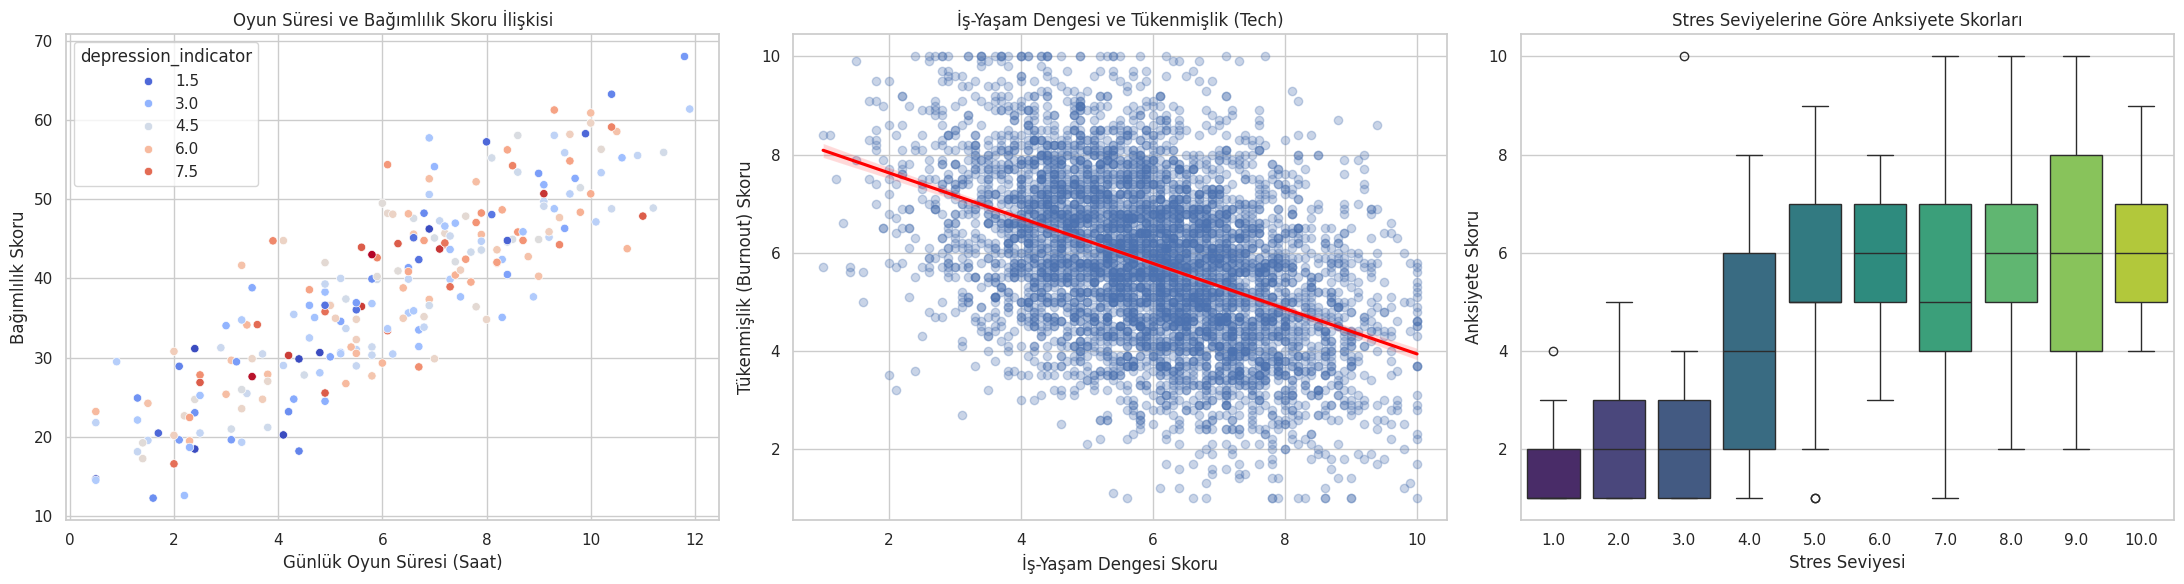

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin genel tarzını ayarlayalım
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Grafik: Oyun Süresi vs Bağımlılık Skoru (Gaming)
sns.scatterplot(data=df_gaming, x='daily_playtime_hours', y='addiction_score', 
                hue='depression_indicator', palette='coolwarm', ax=axes[0])
axes[0].set_title('Oyun Süresi ve Bağımlılık Skoru İlişkisi')
axes[0].set_xlabel('Günlük Oyun Süresi (Saat)')
axes[0].set_ylabel('Bağımlılık Skoru')

# 2. Grafik: İş-Yaşam Dengesi vs Tükenmişlik (Tech)
sns.regplot(data=df_tech, x='work_life_balance_score', y='burnout_score', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('İş-Yaşam Dengesi ve Tükenmişlik (Tech)')
axes[1].set_xlabel('İş-Yaşam Dengesi Skoru')
axes[1].set_ylabel('Tükenmişlik (Burnout) Skoru')

# 3. Grafik: Stres Seviyesi ve Anksiyete Dağılımı (Mental Health)
sns.boxplot(data=df_mental_clean, x='stress_level', y='anxiety_score', palette='viridis', ax=axes[2])
axes[2].set_title('Stres Seviyelerine Göre Anksiyete Skorları')
axes[2].set_xlabel('Stres Seviyesi')
axes[2].set_ylabel('Anksiyete Skoru')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Kümeleme için kritik özellikleri seçelim
features = ['daily_playtime_hours', 'addiction_score', 'stress_score']
X = df_gaming[features]

# 2. Veriyi ölçeklendirelim (K-Means öncesi standartlaştırma şarttır)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 3 Küme (Cluster) ile K-Means modelini eğitelim
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_gaming['risk_cluster'] = kmeans.fit_predict(X_scaled)

# 4. Oluşan kümelerin profillerini (ortalamalarını) görelim
print("--- Oyuncu Küme Profilleri (Ortalamalar) ---")
cluster_profile = df_gaming.groupby('risk_cluster')[features + ['sleep_hours', 'age']].mean()
display(cluster_profile)

--- Oyuncu Küme Profilleri (Ortalamalar) ---


,daily_playtime_hours,addiction_score,stress_score,sleep_hours,age
risk_cluster,,,,,
0,5.109091,32.939610,7.611688,7.120779,22.415584
1,3.053448,26.106724,5.013793,7.324138,22.137931
2,8.415652,49.005043,7.199130,6.247826,22.000000


In [9]:
# Oyun bağımlıları ile Tech çalışanlarının stres/tükenmişlik karşılaştırması
print("--- Kırmızı Alarm Grubu (Küme 2) Ortalama Stres Skoru ---")
print(df_gaming[df_gaming['risk_cluster'] == 2]['stress_score'].mean())

print("\n--- Tech Çalışanları Ortalama Tükenmişlik (Burnout) Skoru ---")
print(df_tech['burnout_score'].mean())

print("\n--- Uzaktan (Remote) vs Ofisten Çalışan Tech Personelinin Tükenmişlik Dağılımı ---")
display(df_tech.groupby('work_arrangement')['burnout_score'].mean())

--- Kırmızı Alarm Grubu (Küme 2) Ortalama Stres Skoru ---
7.1991304347826075

--- Tech Çalışanları Ortalama Tükenmişlik (Burnout) Skoru ---
5.795059999999999

--- Uzaktan (Remote) vs Ofisten Çalışan Tech Personelinin Tükenmişlik Dağılımı ---


work_arrangement
Hybrid       5.827403
In-person    6.027640
Remote       5.626783
Name: burnout_score, dtype: float64